In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jeep_df = pd.read_csv("export_jeep_pool.csv")
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times
0,0,20,1,1,0.0025,220,NaN,10434|24949|27807|29704|32550|37528|57393|6474...,10034|23616|26474|28371|31318|36728|56894|6340...
1,1,20,0,0,0.0025,234,4373|4374|4376|4377|4379|4382|4383|4384|4386|4...,11357|25341|27225|30328|32137|38534|57986|6455...,10957|24008|25892|28995|30804|37734|57245|6322...
2,2,20,1,1,0.0025,220,NaN,20241|25182|27999|29859|32713|39085|60398|6494...,19841|23849|26666|28526|31589|38285|59065|6361...
3,3,20,0,0,0.0025,220,NaN,20739|25570|27464|30585|32297|39941|61599|6475...,20339|24237|26131|29252|30964|39141|60266|6342...
4,4,20,1,1,0.0025,220,NaN,23081|25330|28230|30207|32821|40250|62481|6520...,21748|23997|26897|28874|31769|39450|61148|6387...
5,5,20,0,0,0.0025,220,NaN,23175|25861|27774|30847|32540|41147|62708|6498...,21842|24528|26441|29514|31301|40347|61375|6365...
6,6,20,1,1,0.0025,220,NaN,23378|25564|28515|30414|32978|41486|62784|6550...,22045|24231|27182|29081|32031|40686|61451|6416...
7,7,20,0,0,0.0025,220,NaN,23334|26093|28051|31104|32694|42426|62944|6523...,22001|24760|26718|29771|31557|41626|61611|6389...
8,8,20,1,1,0.0025,220,NaN,23689|25731|28747|30636|33089|42817|63047|6570...,22356|24398|27414|29303|32215|42017|61714|6436...
9,9,20,0,0,0.0025,220,NaN,23591|26300|28328|31328|32802|43456|63218|6547...,22258|24967|26995|29995|31738|42810|61885|6414...


In [3]:
jeep_df["arrive_times"] = jeep_df["arrive_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["arrive_times"]

0     [10434, 24949, 27807, 29704, 32550, 37528, 573...
1     [11357, 25341, 27225, 30328, 32137, 38534, 579...
2     [20241, 25182, 27999, 29859, 32713, 39085, 603...
3     [20739, 25570, 27464, 30585, 32297, 39941, 615...
4     [23081, 25330, 28230, 30207, 32821, 40250, 624...
5     [23175, 25861, 27774, 30847, 32540, 41147, 627...
6     [23378, 25564, 28515, 30414, 32978, 41486, 627...
7     [23334, 26093, 28051, 31104, 32694, 42426, 629...
8     [23689, 25731, 28747, 30636, 33089, 42817, 630...
9     [23591, 26300, 28328, 31328, 32802, 43456, 632...
10    [23995, 26038, 28998, 30957, 33441, 43789, 633...
11    [23839, 26533, 28592, 31587, 32956, 45302, 634...
12    [24196, 26259, 29329, 31174, 34337, 45953, 635...
13    [24045, 26717, 28804, 31827, 33128, 47572, 637...
14    [24490, 26446, 29603, 31469, 35101, 48264, 638...
15    [24434, 26902, 29024, 32016, 33786, 49295, 640...
16    [24713, 26652, 29813, 31658, 36426, 52235, 640...
17    [24650, 27162, 29231, 32236, 35419, 51915,

In [4]:
jeep_df["embark_times"] = jeep_df["embark_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["embark_times"]

0     [10034, 23616, 26474, 28371, 31318, 36728, 568...
1     [10957, 24008, 25892, 28995, 30804, 37734, 572...
2     [19841, 23849, 26666, 28526, 31589, 38285, 590...
3     [20339, 24237, 26131, 29252, 30964, 39141, 602...
4     [21748, 23997, 26897, 28874, 31769, 39450, 611...
5     [21842, 24528, 26441, 29514, 31301, 40347, 613...
6     [22045, 24231, 27182, 29081, 32031, 40686, 614...
7     [22001, 24760, 26718, 29771, 31557, 41626, 616...
8     [22356, 24398, 27414, 29303, 32215, 42017, 617...
9     [22258, 24967, 26995, 29995, 31738, 42810, 618...
10    [22662, 24705, 27665, 29624, 32641, 43290, 620...
11    [22506, 25200, 27259, 30254, 31995, 44803, 621...
12    [22863, 24926, 27996, 29841, 33537, 45454, 622...
13    [22712, 25384, 27471, 30494, 32281, 47073, 624...
14    [23157, 25113, 28270, 30136, 34301, 47765, 625...
15    [23101, 25569, 27691, 30683, 32986, 48796, 627...
16    [23380, 25319, 28480, 30325, 35626, 51736, 627...
17    [23317, 25829, 27898, 30903, 34619, 51416,

In [5]:
jeep_df["queue_start_times"] = jeep_df["arrive_times"].apply(
    lambda times: [0] + times[:-1]
)



In [6]:
jeep_df["queue_wait_times"] = jeep_df.apply(
    lambda row: [eb - qs  for qs, eb in zip(row["queue_start_times"], row["embark_times"])],
    axis=1
)

In [7]:
jeep_df[["embark_times", "arrive_times", "queue_start_times", "queue_wait_times"]].head()


,embark_times,arrive_times,queue_start_times,queue_wait_times
0,"[10034, 23616, 26474, 28371, 31318, 36728, 568...","[10434, 24949, 27807, 29704, 32550, 37528, 573...","[0, 10434, 24949, 27807, 29704, 32550, 37528, ...","[10034, 13182, 1525, 564, 1614, 4178, 19366, 6..."
1,"[10957, 24008, 25892, 28995, 30804, 37734, 572...","[11357, 25341, 27225, 30328, 32137, 38534, 579...","[0, 11357, 25341, 27225, 30328, 32137, 38534, ...","[10957, 12651, 551, 1770, 476, 5597, 18711, 52..."
2,"[19841, 23849, 26666, 28526, 31589, 38285, 590...","[20241, 25182, 27999, 29859, 32713, 39085, 603...","[0, 20241, 25182, 27999, 29859, 32713, 39085, ...","[19841, 3608, 1484, 527, 1730, 5572, 19980, 32..."
3,"[20339, 24237, 26131, 29252, 30964, 39141, 602...","[20739, 25570, 27464, 30585, 32297, 39941, 615...","[0, 20739, 25570, 27464, 30585, 32297, 39941, ...","[20339, 3498, 561, 1788, 379, 6844, 20325, 182..."
4,"[21748, 23997, 26897, 28874, 31769, 39450, 611...","[23081, 25330, 28230, 30207, 32821, 40250, 624...","[0, 23081, 25330, 28230, 30207, 32821, 40250, ...","[21748, 916, 1567, 644, 1562, 6629, 20898, 139..."


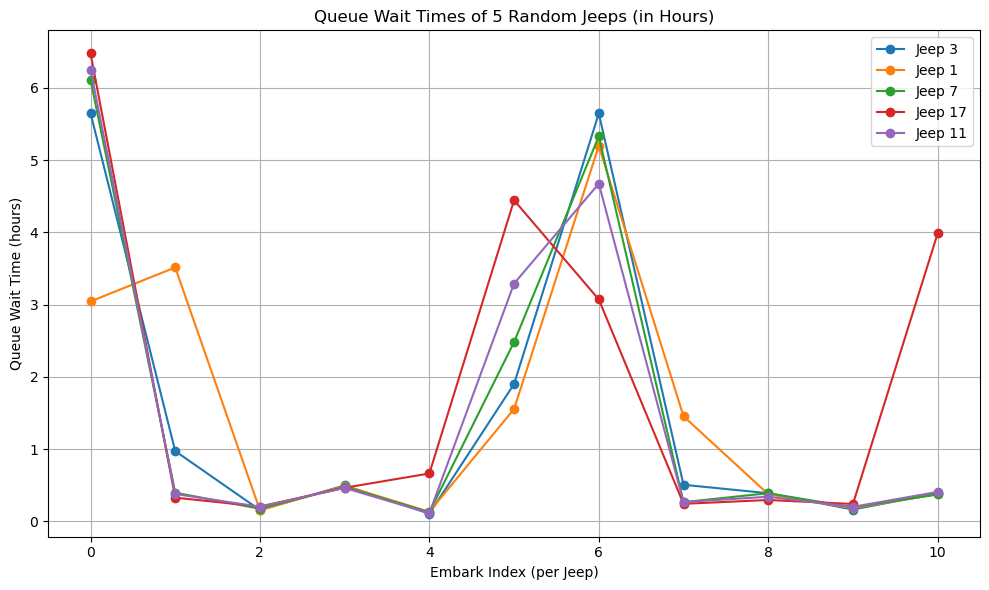

In [28]:
import random

# Randomly select 5 jeep indices
random_indices = random.sample(range(len(jeep_df)), 5)

# Plot each selected jeep's queue wait times (converted to hours)
plt.figure(figsize=(10, 6))
for idx in random_indices:
    wait_times_sec = jeep_df.loc[idx, "queue_wait_times"]
    wait_times_hr = [t / 3600 for t in wait_times_sec]  # Convert to hours
    plt.plot(range(len(wait_times_hr)), wait_times_hr, marker='o', label=f"Jeep {idx}")

plt.xlabel("Embark Index (per Jeep)")
plt.ylabel("Queue Wait Time (hours)")
plt.title("Queue Wait Times of 5 Random Jeeps (in Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
jeep_df["embark_hours"] = jeep_df["embark_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["embark_hours"]

0     [2.79, 6.56, 7.35, 7.88, 8.7, 10.2, 15.8, 17.6...
1     [3.04, 6.67, 7.19, 8.05, 8.56, 10.48, 15.9, 17...
2     [5.51, 6.62, 7.41, 7.92, 8.77, 10.63, 16.41, 1...
3     [5.65, 6.73, 7.26, 8.13, 8.6, 10.87, 16.74, 17...
4     [6.04, 6.67, 7.47, 8.02, 8.82, 10.96, 16.99, 1...
5     [6.07, 6.81, 7.34, 8.2, 8.69, 11.21, 17.05, 17...
6     [6.12, 6.73, 7.55, 8.08, 8.9, 11.3, 17.07, 17....
7     [6.11, 6.88, 7.42, 8.27, 8.77, 11.56, 17.11, 1...
8     [6.21, 6.78, 7.62, 8.14, 8.95, 11.67, 17.14, 1...
9     [6.18, 6.94, 7.5, 8.33, 8.82, 11.89, 17.19, 17...
10    [6.29, 6.86, 7.68, 8.23, 9.07, 12.03, 17.23, 1...
11    [6.25, 7.0, 7.57, 8.4, 8.89, 12.45, 17.26, 17....
12    [6.35, 6.92, 7.78, 8.29, 9.32, 12.63, 17.29, 1...
13    [6.31, 7.05, 7.63, 8.47, 8.97, 13.08, 17.35, 1...
14    [6.43, 6.98, 7.85, 8.37, 9.53, 13.27, 17.37, 1...
15    [6.42, 7.1, 7.69, 8.52, 9.16, 13.55, 17.42, 18...
16    [6.49, 7.03, 7.91, 8.42, 9.9, 14.37, 17.43, 18...
17    [6.48, 7.17, 7.75, 8.58, 9.62, 14.28, 17.4

In [10]:
jeep_df["arrive_hours"] = jeep_df["arrive_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["arrive_hours"]

0     [2.9, 6.93, 7.72, 8.25, 9.04, 10.42, 15.94, 17...
1     [3.15, 7.04, 7.56, 8.42, 8.93, 10.7, 16.11, 17...
2     [5.62, 7.0, 7.78, 8.29, 9.09, 10.86, 16.78, 18...
3     [5.76, 7.1, 7.63, 8.5, 8.97, 11.09, 17.11, 17....
4     [6.41, 7.04, 7.84, 8.39, 9.12, 11.18, 17.36, 1...
5     [6.44, 7.18, 7.71, 8.57, 9.04, 11.43, 17.42, 1...
6     [6.49, 7.1, 7.92, 8.45, 9.16, 11.52, 17.44, 18...
7     [6.48, 7.25, 7.79, 8.64, 9.08, 11.79, 17.48, 1...
8     [6.58, 7.15, 7.99, 8.51, 9.19, 11.89, 17.51, 1...
9     [6.55, 7.31, 7.87, 8.7, 9.11, 12.07, 17.56, 18...
10    [6.67, 7.23, 8.05, 8.6, 9.29, 12.16, 17.6, 18....
11    [6.62, 7.37, 7.94, 8.77, 9.15, 12.58, 17.63, 1...
12    [6.72, 7.29, 8.15, 8.66, 9.54, 12.76, 17.66, 1...
13    [6.68, 7.42, 8.0, 8.84, 9.2, 13.21, 17.72, 18....
14    [6.8, 7.35, 8.22, 8.74, 9.75, 13.41, 17.74, 18...
15    [6.79, 7.47, 8.06, 8.89, 9.38, 13.69, 17.79, 1...
16    [6.86, 7.4, 8.28, 8.79, 10.12, 14.51, 17.8, 18...
17    [6.85, 7.54, 8.12, 8.95, 9.84, 14.42, 17.8

In [11]:
jeep_df["gross_profit"] = jeep_df["passenger_served"] * 13

jeep_df["gross_profit"]

0     2860
1     3042
2     2860
3     2860
4     2860
5     2860
6     2860
7     2860
8     2860
9     2860
10    2860
11    2860
12    2860
13    2860
14    2860
15    2860
16    2860
17    2860
18    2860
19    2691
Name: gross_profit, dtype: int64

In [12]:
route_distance = 5 #change if needed
gas_price = 60
liters_per_km = 0.181818
jeep_df["gas_expense"] = len(jeep_df["embark_times"]) * route_distance * liters_per_km * gas_price

In [13]:
jeep_df["gas_expense"]

0     1090.908
1     1090.908
2     1090.908
3     1090.908
4     1090.908
5     1090.908
6     1090.908
7     1090.908
8     1090.908
9     1090.908
10    1090.908
11    1090.908
12    1090.908
13    1090.908
14    1090.908
15    1090.908
16    1090.908
17    1090.908
18    1090.908
19    1090.908
Name: gas_expense, dtype: float64

In [14]:
jeep_df["net_profit"] = jeep_df["gross_profit"] - jeep_df["gas_expense"]

In [15]:
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times,queue_start_times,queue_wait_times,embark_hours,arrive_hours,gross_profit,gas_expense,net_profit
0,0,20,1,1,0.0025,220,NaN,"[10434, 24949, 27807, 29704, 32550, 37528, 573...","[10034, 23616, 26474, 28371, 31318, 36728, 568...","[0, 10434, 24949, 27807, 29704, 32550, 37528, ...","[10034, 13182, 1525, 564, 1614, 4178, 19366, 6...","[2.79, 6.56, 7.35, 7.88, 8.7, 10.2, 15.8, 17.6...","[2.9, 6.93, 7.72, 8.25, 9.04, 10.42, 15.94, 17...",2860,1090.908,1769.092
1,1,20,0,0,0.0025,234,4373|4374|4376|4377|4379|4382|4383|4384|4386|4...,"[11357, 25341, 27225, 30328, 32137, 38534, 579...","[10957, 24008, 25892, 28995, 30804, 37734, 572...","[0, 11357, 25341, 27225, 30328, 32137, 38534, ...","[10957, 12651, 551, 1770, 476, 5597, 18711, 52...","[3.04, 6.67, 7.19, 8.05, 8.56, 10.48, 15.9, 17...","[3.15, 7.04, 7.56, 8.42, 8.93, 10.7, 16.11, 17...",3042,1090.908,1951.092
2,2,20,1,1,0.0025,220,NaN,"[20241, 25182, 27999, 29859, 32713, 39085, 603...","[19841, 23849, 26666, 28526, 31589, 38285, 590...","[0, 20241, 25182, 27999, 29859, 32713, 39085, ...","[19841, 3608, 1484, 527, 1730, 5572, 19980, 32...","[5.51, 6.62, 7.41, 7.92, 8.77, 10.63, 16.41, 1...","[5.62, 7.0, 7.78, 8.29, 9.09, 10.86, 16.78, 18...",2860,1090.908,1769.092
3,3,20,0,0,0.0025,220,NaN,"[20739, 25570, 27464, 30585, 32297, 39941, 615...","[20339, 24237, 26131, 29252, 30964, 39141, 602...","[0, 20739, 25570, 27464, 30585, 32297, 39941, ...","[20339, 3498, 561, 1788, 379, 6844, 20325, 182...","[5.65, 6.73, 7.26, 8.13, 8.6, 10.87, 16.74, 17...","[5.76, 7.1, 7.63, 8.5, 8.97, 11.09, 17.11, 17....",2860,1090.908,1769.092
4,4,20,1,1,0.0025,220,NaN,"[23081, 25330, 28230, 30207, 32821, 40250, 624...","[21748, 23997, 26897, 28874, 31769, 39450, 611...","[0, 23081, 25330, 28230, 30207, 32821, 40250, ...","[21748, 916, 1567, 644, 1562, 6629, 20898, 139...","[6.04, 6.67, 7.47, 8.02, 8.82, 10.96, 16.99, 1...","[6.41, 7.04, 7.84, 8.39, 9.12, 11.18, 17.36, 1...",2860,1090.908,1769.092
5,5,20,0,0,0.0025,220,NaN,"[23175, 25861, 27774, 30847, 32540, 41147, 627...","[21842, 24528, 26441, 29514, 31301, 40347, 613...","[0, 23175, 25861, 27774, 30847, 32540, 41147, ...","[21842, 1353, 580, 1740, 454, 7807, 20228, 943...","[6.07, 6.81, 7.34, 8.2, 8.69, 11.21, 17.05, 17...","[6.44, 7.18, 7.71, 8.57, 9.04, 11.43, 17.42, 1...",2860,1090.908,1769.092
6,6,20,1,1,0.0025,220,NaN,"[23378, 25564, 28515, 30414, 32978, 41486, 627...","[22045, 24231, 27182, 29081, 32031, 40686, 614...","[0, 23378, 25564, 28515, 30414, 32978, 41486, ...","[22045, 853, 1618, 566, 1617, 7708, 19965, 138...","[6.12, 6.73, 7.55, 8.08, 8.9, 11.3, 17.07, 17....","[6.49, 7.1, 7.92, 8.45, 9.16, 11.52, 17.44, 18...",2860,1090.908,1769.092
7,7,20,0,0,0.0025,220,NaN,"[23334, 26093, 28051, 31104, 32694, 42426, 629...","[22001, 24760, 26718, 29771, 31557, 41626, 616...","[0, 23334, 26093, 28051, 31104, 32694, 42426, ...","[22001, 1426, 625, 1720, 453, 8932, 19185, 955...","[6.11, 6.88, 7.42, 8.27, 8.77, 11.56, 17.11, 1...","[6.48, 7.25, 7.79, 8.64, 9.08, 11.79, 17.48, 1...",2860,1090.908,1769.092
8,8,20,1,1,0.0025,220,NaN,"[23689, 25731, 28747, 30636, 33089, 42817, 630...","[22356, 24398, 27414, 29303, 32215, 42017, 617...","[0, 23689, 25731, 28747, 30636, 33089, 42817, ...","[22356, 709, 1683, 556, 1579, 8928, 18897, 132...","[6.21, 6.78, 7.62, 8.14, 8.95, 11.67, 17.14, 1...","[6.58, 7.15, 7.99, 8.51, 9.19, 11.89, 17.51, 1...",2860,1090.908,1769.092
9,9,20,0,0,0.0025,220,NaN,"[23591, 26300, 28328, 31328, 32802, 43456, 632...","[22258, 24967, 26995, 29995, 31738, 42810, 618...","[0, 23591, 26300, 28328, 31328, 32802, 43456, ...","[22258, 1376, 695, 1667, 410, 10008, 18429, 92...","[6.18, 6.94, 7.5, 8.33, 8.82, 11.89, 17.19, 17...","[6.55, 7.31, 7.87, 8.7, 9.11, 12.07, 17.56, 18...",2860,1090.908,1769.092


In [16]:
passenger_df = pd.read_csv("export_passenger_pool.csv")

passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]] = passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]].apply(lambda times: [round(int(t) / 3600, 2) for t in times] )

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal
0,0,0.04,0.04,3.04,3.15,1,1
1,1,0.04,0.04,2.79,2.90,0,0
2,2,0.08,0.08,3.04,3.15,1,1
3,3,0.38,0.38,2.79,2.90,0,0
4,4,0.40,0.40,2.79,2.90,0,0
...,...,...,...,...,...,...,...
4396,4396,23.90,23.90,0.00,0.00,19,1
4397,4397,23.91,23.91,0.00,0.00,1,0
4398,4398,23.92,23.92,0.00,0.00,19,1
4399,4399,23.93,23.93,0.00,0.00,1,0


In [17]:
passenger_df["turn_around_time"] = passenger_df["destination_arrival_time"] - passenger_df["terminal_arrival_time"]

passenger_df = passenger_df[passenger_df["turn_around_time"] > 0]

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.04,0.04,3.04,3.15,1,1,3.11
1,1,0.04,0.04,2.79,2.90,0,0,2.86
2,2,0.08,0.08,3.04,3.15,1,1,3.07
3,3,0.38,0.38,2.79,2.90,0,0,2.52
4,4,0.40,0.40,2.79,2.90,0,0,2.50
...,...,...,...,...,...,...,...,...
4380,4380,23.12,23.12,23.73,23.86,17,1,0.74
4381,4381,23.22,23.22,23.73,23.86,17,1,0.64
4385,4385,23.68,23.68,23.73,23.86,17,1,0.18
4388,4388,23.71,23.71,23.73,23.86,17,1,0.15


In [18]:
terminal_0_df = passenger_df[passenger_df["terminal"] == 0]
terminal_1_df = passenger_df[passenger_df["terminal"] == 1]


In [19]:
terminal_0_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
1,1,0.04,0.04,2.79,2.90,0,0,2.86
3,3,0.38,0.38,2.79,2.90,0,0,2.52
4,4,0.40,0.40,2.79,2.90,0,0,2.50
7,7,0.74,0.74,2.79,2.90,0,0,2.16
8,8,0.76,0.76,2.79,2.90,0,0,2.14
...,...,...,...,...,...,...,...,...
4363,4363,22.57,22.57,22.90,23.02,18,0,0.45
4364,4364,22.61,22.61,22.90,23.02,18,0,0.41
4366,4366,22.74,22.74,22.90,23.02,18,0,0.28
4371,4371,22.85,22.85,22.90,23.02,18,0,0.17


In [20]:
terminal_1_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.04,0.04,3.04,3.15,1,1,3.11
2,2,0.08,0.08,3.04,3.15,1,1,3.07
5,5,0.47,0.47,3.04,3.15,1,1,2.68
6,6,0.67,0.67,3.04,3.15,1,1,2.48
10,10,0.87,0.87,3.04,3.15,1,1,2.28
...,...,...,...,...,...,...,...,...
4380,4380,23.12,23.12,23.73,23.86,17,1,0.74
4381,4381,23.22,23.22,23.73,23.86,17,1,0.64
4385,4385,23.68,23.68,23.73,23.86,17,1,0.18
4388,4388,23.71,23.71,23.73,23.86,17,1,0.15


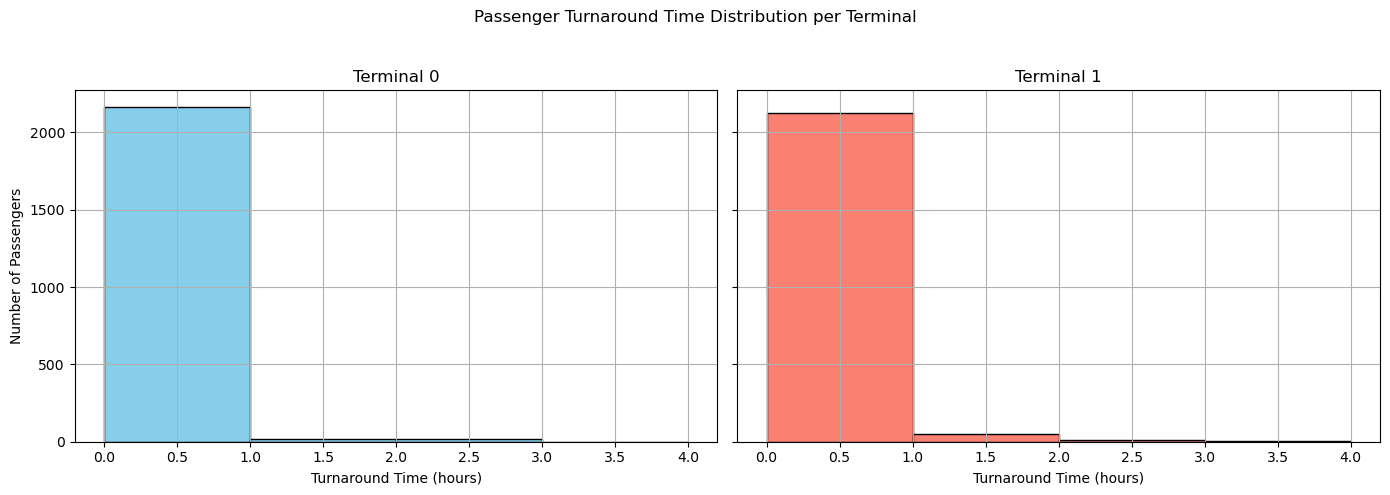

In [21]:

# Define bins (hourly intervals)
max_turnaround = max(terminal_0_df["turn_around_time"].max(), terminal_1_df["turn_around_time"].max())
bins = range(0, int(max_turnaround) + 2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Terminal 0 histogram
axs[0].hist(terminal_0_df["turn_around_time"], bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title("Terminal 0")
axs[0].set_xlabel("Turnaround Time (hours)")
axs[0].set_ylabel("Number of Passengers")
axs[0].grid(True)

# Terminal 1 histogram
axs[1].hist(terminal_1_df["turn_around_time"], bins=bins, color='salmon', edgecolor='black')
axs[1].set_title("Terminal 1")
axs[1].set_xlabel("Turnaround Time (hours)")
axs[1].grid(True)

plt.suptitle("Passenger Turnaround Time Distribution per Terminal")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

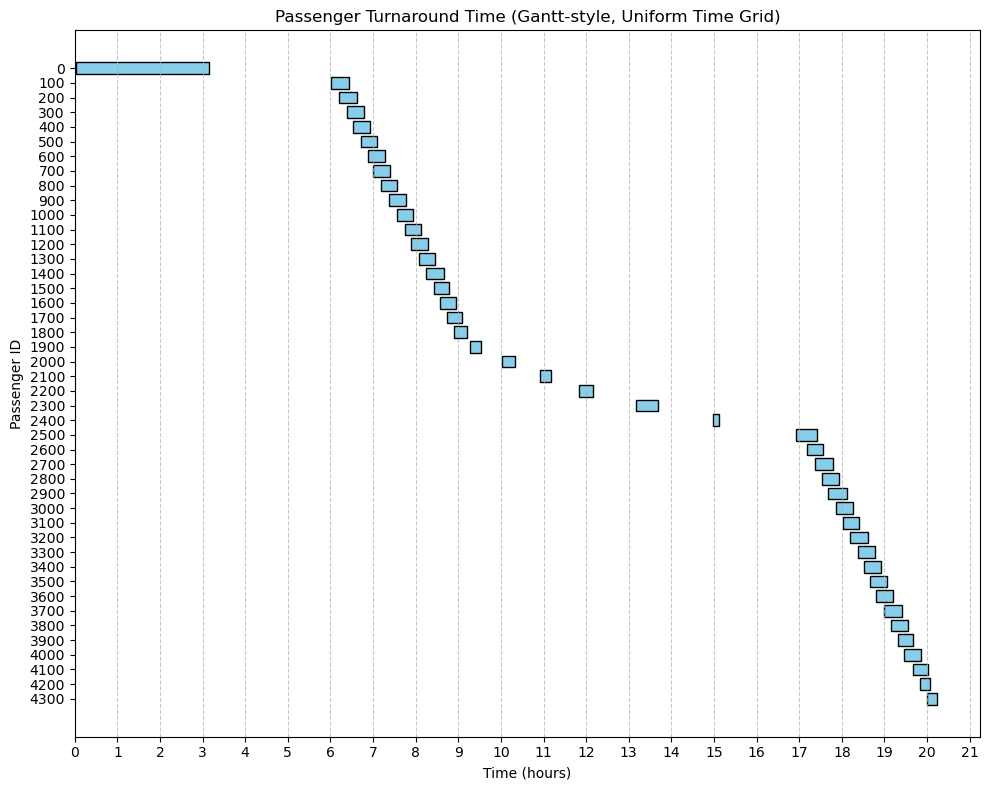

In [22]:

sample_df = passenger_df.iloc[::100].copy()

# Sample by index increments (e.g., every 100th row)
sample_df = passenger_df.iloc[::100].copy()

# Prepare data
starts = sample_df["terminal_arrival_time"]
durations = sample_df["turn_around_time"]
passenger_ids = sample_df["passenger_id"].astype(str)

# Set figure
plt.figure(figsize=(10, 8))
plt.barh(passenger_ids, durations, left=starts, color='skyblue', edgecolor='black')

# Set x-axis gridlines and ticks at every 1 hour
xmin = int(sample_df["terminal_arrival_time"].min())
xmax = int(sample_df["destination_arrival_time"].max()) + 1
plt.xticks(np.arange(xmin, xmax + 1, 1))  # every 1 hour
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Labels and layout
plt.xlabel("Time (hours)")
plt.ylabel("Passenger ID")
plt.title("Passenger Turnaround Time (Gantt-style, Uniform Time Grid)")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

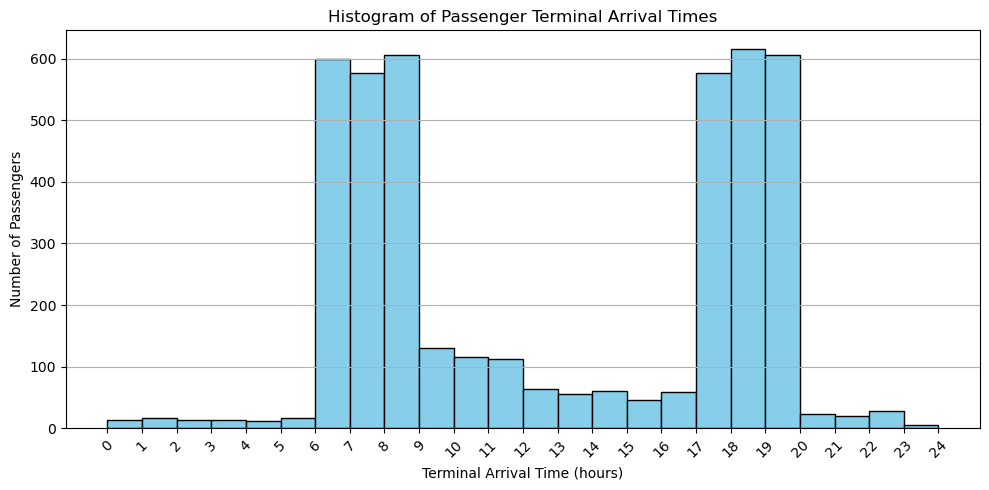

In [23]:
# Define bins: from min to max time, 1-hour step
min_time = int(passenger_df["terminal_arrival_time"].min())
max_time = int(passenger_df["terminal_arrival_time"].max()) + 1
bins = np.arange(min_time, max_time + 1, 1)  # 1-hour bins

# Plot
plt.figure(figsize=(10, 5))
plt.hist(passenger_df["terminal_arrival_time"], bins=bins, color='skyblue', edgecolor='black')

# Labels and styling
plt.xlabel("Terminal Arrival Time (hours)")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Terminal Arrival Times")
plt.grid(True, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()